In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

#### Numpy ver 1.16+ incompatiblity solution with fastai=0.7

In [2]:
import fastai.model
#import numpy as np

# 1. Fix the printing crash
def fixed_print_stats(epoch, values, decimals=6):
    layout = "{!s:^10}" + " {!s:10}" * len(values)
    # Convert each item to float and round it individually
    clean_values = [round(float(v), decimals) for v in values]
    print(layout.format(*( [epoch] + clean_values )))

# 2. Fix the history saving crash (your current error)
def fixed_append_stats(ep_vals, epoch, values, decimals=6):
    # Convert each item to float and round it individually
    ep_vals[epoch] = [round(float(v), decimals) for v in values]
    return ep_vals

# Overwrite both library functions with the fixed versions
fastai.model.print_stats = fixed_print_stats
fastai.model.append_stats = fixed_append_stats

print("✅ Patches applied: print_stats and append_stats are now NumPy 1.16+ compatible.")

✅ Patches applied: print_stats and append_stats are now NumPy 1.16+ compatible.


### The TrainPhase API

In [3]:
from fastai.conv_learner import *
PATH = Path('../data/cifar10/')

In [4]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
stats = (np.array([ 0.4914 ,  0.48216,  0.44653]), np.array([ 0.24703,  0.24349,  0.26159]))

In [5]:
def get_data(sz, bs):
    tfms = tfms_from_stats(stats, sz, aug_tfms=[RandomFlip()], pad=sz//8)
    return ImageClassifierData.from_paths(PATH, val_name='test', tfms=tfms, bs=bs)

In [6]:
size = 32
batch_size = 64

In [7]:
data = get_data(size, batch_size)

In [8]:
def SimpleNet(layers):
    list_layers = [Flatten()]
    for i in range(len(layers)-1):
        list_layers.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers)-2: list_layers.append(nn.ReLU(inplace=True))
        else: list_layers.append(nn.LogSoftmax(dim=0))
    return nn.Sequential(*list_layers)

In [9]:
learn = ConvLearner.from_model_data(SimpleNet([32*32*3, 40, 10]), data)

Now we can use our learner object to give examples of traning.

With the new API, you don't use a pre-implemented training schedule but you can design your own with object called TrainingPhase. A training phase is just a class that will record all the parameters you want to apply during this part of the training loop, specifically:

- a number of epochs for which these settings will be valid (can be a float)
- an optimizer function (SGD, RMSProp, Adam...)
- a learning rate (or array of lrs) or a range of learning rates (or array of lrs) if you want to change the lr.
- a learning rate decay method (that will explain how you want to change the lr)
- a momentum (which will beta1 if you're using Adam), or a range of momentums if you want to change it
- a momentum decay method (that will explain how you want to change the momentum, if applicable)
- optionally a weight decay (or array of wds)
- optionally a beta parameter (which is the RMSProp alpha or the Adam beta2, if you want another vlaue than default)
  
By combining those blocks as you wish, you can implement pretty much any method of training you could think of.
#### Basic lr decay

In [10]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-2), TrainingPhase(epochs=2, opt_fn=optim.SGD, lr= 1e-3)]

In [11]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.623994   4.558499   0.1408    
    1      3.483678   4.515695   0.1431                     
    2      3.488362   4.512152   0.1425                     


[array([4.51215]), 0.1425]

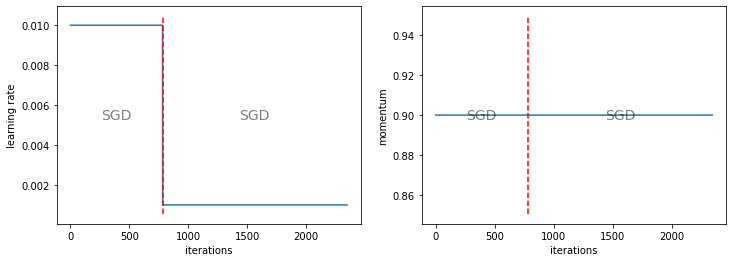

In [12]:
learn.sched.plot_lr()

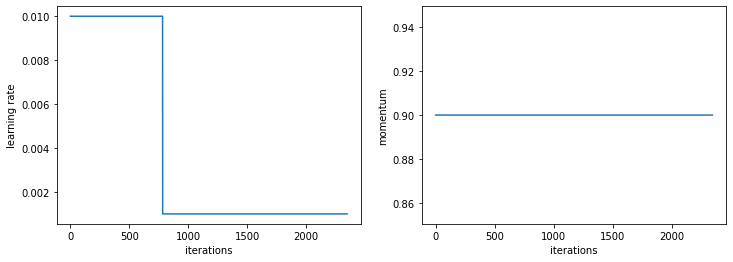

In [13]:
learn.sched.plot_lr(show_text=False)

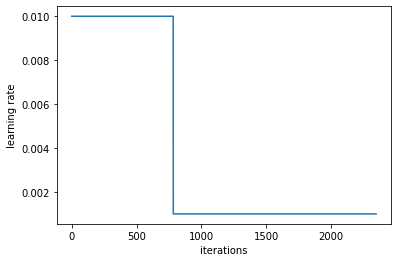

In [14]:
learn.sched.plot_lr(show_text=False, show_moms=False)

#### Linear LR Decay

In [15]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=(1e-2,1e-3), lr_decay=DecayType.LINEAR),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-3)]

In [16]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                    
    0      3.589953   4.577654   0.1342    
    1      3.467058   4.526733   0.1431                     
    2      3.45815    4.522083   0.1406                      


[array([4.52208]), 0.1406]

In [17]:
#lr_i = start_lr + (end_lr - start_lr) * i/n
#(to run the cell above give a value to all the parameters: start_lr, end_lr, i and n)

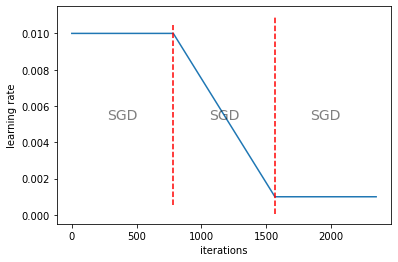

In [18]:
learn.sched.plot_lr(show_moms=False)

### Cosine LR Decay

In [19]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=(1e-2,1e-3), lr_decay=DecayType.COSINE),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-3)]

In [20]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.552153   4.579333   0.1378    
    1      3.451059   4.532367   0.1436                      
    2      3.456602   4.53472    0.1419                     


[array([4.53472]), 0.1419]

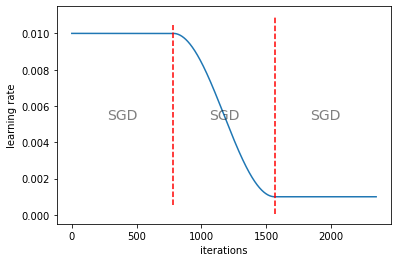

In [21]:
learn.sched.plot_lr(show_moms=False)

### Exponential LR Decay

In [22]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=(1e-2,1e-3), lr_decay=DecayType.EXPONENTIAL),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-3)]

In [23]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.555566   4.606078   0.1294    
    1      3.42517    4.543494   0.1403                     
    2      3.411646   4.547632   0.1433                      


[array([4.54763]), 0.1433]

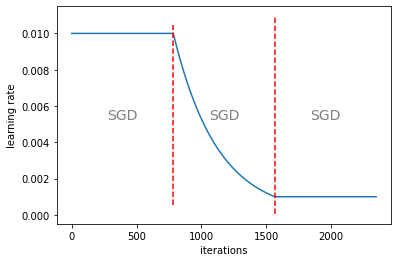

In [24]:
learn.sched.plot_lr(show_moms=False)

#### Polynomial of power 2 Lr Decay

In [25]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=(1e-2,1e-3), lr_decay=(DecayType.POLYNOMIAL,2)),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-3)]

In [26]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                    
    0      3.554924   4.659381   0.1363    
    1      3.42946    4.558537   0.147                      
    2      3.415085   4.563627   0.1449                     


[array([4.56363]), 0.1449]

In [ ]:
lr_i = end_lr + (start_lr - end_lr) * (1 - 1/n) ** p

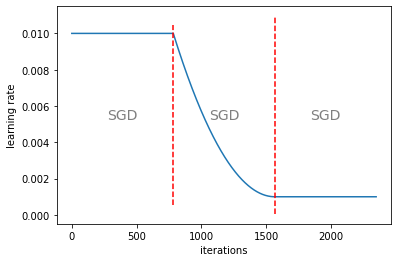

In [28]:
learn.sched.plot_lr(show_moms=False)

### Polynomial of power 0.5 Lr Decay

In [29]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=(1e-2,1e-3), lr_decay=(DecayType.POLYNOMIAL, 0.5)),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-3)]

In [30]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.534455   4.63011    0.1397    
    1      3.464071   4.534245   0.143                       
    2      3.410487   4.547723   0.1471                      


[array([4.54772]), 0.1471]

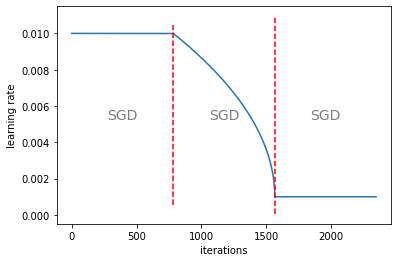

In [31]:
learn.sched.plot_lr(show_moms=False)

 ###### Cosine LR Decay with out giving end_lr(default is 0)

In [32]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr=1e-2, lr_decay=DecayType.COSINE),
         TrainingPhase(epochs=1, opt_fn=optim.SGD, lr= 1e-3)]

In [33]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                    
    0      3.542664   4.584998   0.1309    
    1      3.425084   4.542876   0.1428                     
    2      3.406694   4.548267   0.145                       


[array([4.54827]), 0.145]

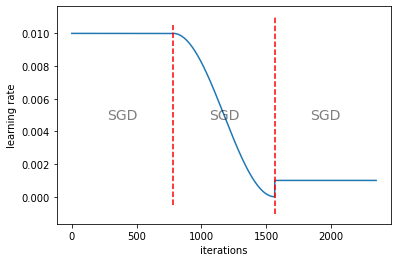

In [34]:
learn.sched.plot_lr(show_moms=False)

 ### SGDR
 The traditional stochastic gradient with restart we used requires three arguments:

- the number of cycles
- the length of a cycle (cycle_len)
- the value by which we should multiply the cycle_len after each cycle (cycle_mult)
Also, note there is a warm-up at constant lr of 1/100th of the max value during 1/20th of the first cycle.

This can easily be implemented in a function (which you should now try to do by yourself) which creates a list of phases (number of cycles + 1 here). Remember you can have a float number for the epochs in a Training Phase.

In [35]:
def phases_sgdr(lr, opt_fn, num_cycle, cycle_len, cycle_mult):
    phases = [TrainingPhase(epochs = cycle_len/ 20, opt_fn=opt_fn, lr=lr/100),
             TrainingPhase(epochs = cycle_len * 19/20, opt_fn=opt_fn, lr=lr, lr_decay=DecayType.COSINE)]
    for i in range(1, num_cycle):
        phases.append(TrainingPhase(epochs = cycle_len * (cycle_mult**i), opt_fn=opt_fn, lr=lr, lr_decay=DecayType.COSINE))
    return phases

In [36]:
learn.fit_opt_sched(phases_sgdr(1e-2, optim.Adam, 2, 1, 2))

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.543024   4.474585   0.1388    
    1      3.770355   4.548304   0.1409                     
    2      3.548275   4.505624   0.1405                     


[array([4.50562]), 0.1405]

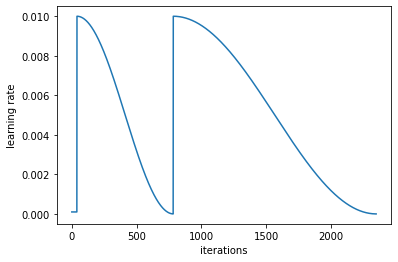

In [37]:
learn.sched.plot_lr(show_text=False, show_moms=False)

### 1cycle
Leslie Smith's 1cycle policy states to pick a maximum learning rate with our traditional learning rate finder, choose a factor div by which to divide this learning rate, then do two phases of equal length going linearly from our minimal lr to our maximal lr, then back to the minimum.

In parallel, the momentum should begin high (like 0.95) and decrease to a minimum (like 0.85) as the lr grows, then returns to the maximum as the lr decreases.

To complete this cycle, allow a bit of time to let the learning rate decrease even more at the end (I chose to go from the minimum_lr to 1/100th of its value linearly since it was the thing that seemed to work the best in my experiments).

So let's create a function 1cycle that takes the arguments:

- cycle_len: the total length of the cycle (in epochs)
- lr: the maximum learning rate
- div: by how much do we want to divide the maximum lr
- pct: what percentage of epochs should be left at the end for the final annealing
- max_mom: the maximum momentum
- min_mom: the minimum momentum
The optim function should be SGD (with momentum).

In [38]:
def phases_1cycle(cycle_len, lr, div, pct, max_mom, min_mom):
    tri_cyc = (1-pct/100) * cycle_len
    return [TrainingPhase(epochs=tri_cyc/2, opt_fn=optim.SGD, lr =(lr/div, lr), lr_decay=DecayType.LINEAR,
                         momentum=(max_mom, min_mom), momentum_decay=DecayType.LINEAR),
            TrainingPhase(epochs=tri_cyc/2, opt_fn=optim.SGD, lr = (lr, lr/div), lr_decay=DecayType.LINEAR,
                         momentum=(min_mom,max_mom), momentum_decay=DecayType.LINEAR),
            TrainingPhase(epochs=cycle_len-tri_cyc, opt_fn=optim.SGD, lr=(lr/div,lr/(100*div)), lr_decay=DecayType.LINEAR,
                         momentum=max_mom)]

In [39]:
learn.fit_opt_sched(phases_1cycle(3, 1e-2, 10, 10, 0.95, 0.85))

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.955514   5.058865   0.1166    
    1      3.820564   4.86381    0.1295                      
    2      3.562781   4.533052   0.1381                      


[array([4.53305]), 0.1381]

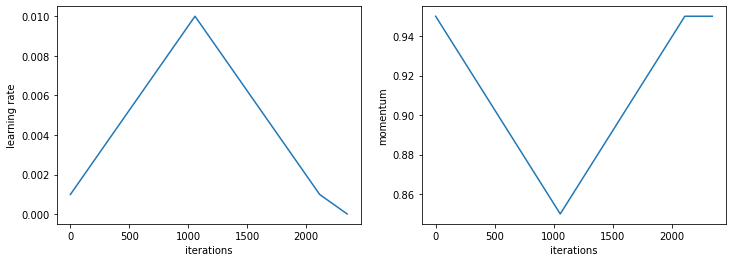

In [40]:
learn.sched.plot_lr(show_text=False)

#### Discriminative learning rates
When you unfreeze a pretrained model, you often use differential learning rates, and this works with this new API too. Just pass an array or a list of learning rates instead of a single value.

In [ ]:
learn = ConvLearner.pretrained(resnet34, data, metrics=[accuracy])
#learn = ConvLearner.pretrained(SimpleNet([32*32*3, 40, 10]), data, metrics=[accuracy])

In [ ]:
learn.unfreeze()
lr = 1e-2
lrs = np.array([lr/100, lr/10,lr])

In [ ]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.Adam, lr=(lrs/10, lrs), lr_decay=DecayType.LINEAR),
         TrainingPhase(epochs=2, opt_fn=optim.Adam, lr=lrs, lr_decay=DecayType.COSINE)]

In [ ]:
learn.fit_opt_sched(phases)

In [ ]:
learn.sched.plot_lr(show_text=False, show_moms=False)

### Customized Lr finder
This API can also be used to run a learning rate finder: just put a very low starting LR and a very large ending one, and choose exponential or linear decay. To stop when the loss go wild, we add the option stop_div= True. This can also be used in a regular fit if you want to stop the training in case the loss suddenly spikes.

As you can choose the number of epochs, this is particularly useful when you have a small dataset (you can run more epoxhs to have a clearer curve) or a very large one where a fraction of an epoch is plenty. In general 100-200 values are plenty to have a clear curve, so since we know we have 782 batches on cifar10, we'll run this customized LR Finder on 0.25 epochs.

In [41]:
phases = [TrainingPhase(epochs=0.25, opt_fn=optim.SGD, lr=(1e-5,10), lr_decay=DecayType.EXPONENTIAL, momentum=0.9)]

In [43]:
learn = ConvLearner.from_model_data(SimpleNet([32*32*3, 40, 10]), data)

In [44]:
learn.save('tmp')
learn.fit_opt_sched(phases, stop_div=True)
learn.load('tmp')

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

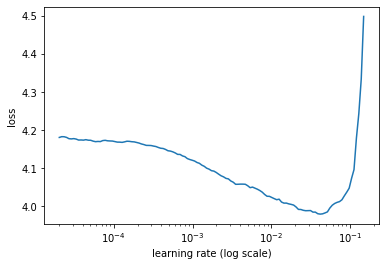

In [45]:
learn.sched.plot()

In [49]:
phases = [TrainingPhase(epochs=0.25, opt_fn=optim.SGD, lr=(0.001, 0.1), lr_decay=DecayType.LINEAR, momentum=0.9)]
learn.save('tmp')
learn.fit_opt_sched(phases, stop_div=True)
learn.load('tmp')

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

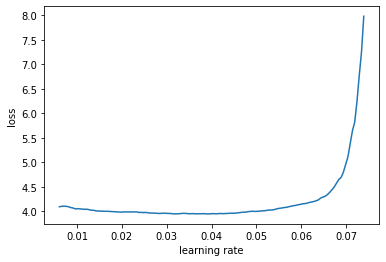

In [50]:
learn.sched.plot()

In [52]:
phases = [TrainingPhase(epochs=0.25, opt_fn=optim.SGD, lr=(1e-5, 10), lr_decay=DecayType.EXPONENTIAL, momentum=0.9)]
learn.save('tmp')
learn.fit_opt_sched(phases, stop_div=True)
learn.load('tmp')

Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

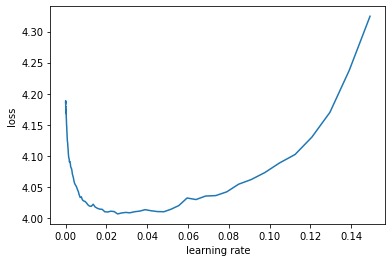

In [53]:
learn.sched.plot(linear=True)

### But there's more!
The first thing that's possible with these blocks and didn't try yet is that you can change the optimizer at each phase. For instance, we can do a 1cycle with SGD and cyclical momentum but then anneal with Adam.

In [54]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.SGD, lr =(1e-3,1e-2), lr_decay=DecayType.LINEAR,
                         momentum=(0.95, 0.85), momentum_decay=DecayType.LINEAR),
            TrainingPhase(epochs=1, opt_fn=optim.SGD, lr = (1e-2,1e-3), lr_decay=DecayType.LINEAR,
                         momentum=(0.85, 0.95), momentum_decay=DecayType.LINEAR),
            TrainingPhase(epochs=1, opt_fn=optim.Adam, lr=1e-3, lr_decay=DecayType.COSINE, momentum=0.9)]

In [55]:
learn.fit_opt_sched(phases)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.595923   4.508665   0.1292    
    1      3.510141   4.509386   0.1374                     
    2      3.468401   4.504454   0.1379                      


[array([4.50445]), 0.1379]

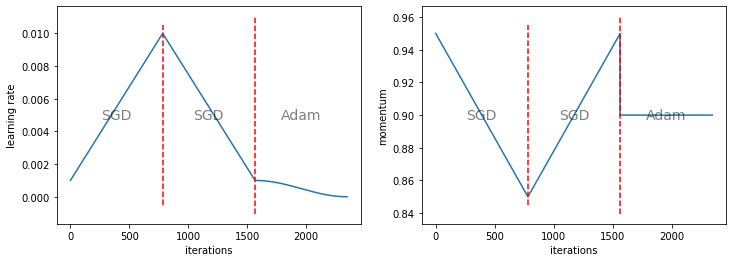

In [56]:
learn.sched.plot_lr()

Lastly, you can even change your data during the training. This is only applicable for a full CNN that can works with any size, but you could decide to train it for a bit with a smaller size before increasing it.

In [57]:
def ConvBN(n_in, n_out, stride):
    return nn.Sequential(nn.Conv2d(n_in, n_out, 3, stride=stride,padding=1), nn.BatchNorm2d(n_out))

In [58]:
def ShallowConvNet():
    listlayers = [ConvBN(3, 64, 20), nn.ReLU(inplace=True), ConvBN(64, 128, 2), nn.ReLU(inplace=True),
                 nn.AdaptiveAvgPool2d(1), Flatten(), nn.Linear(128, 10), nn.LogSoftmax(dim=0)]
    return nn.Sequential(*listlayers)

In [59]:
data1 = get_data(28, batch_size)
data2 = get_data(32, batch_size)

In [61]:
learn = ConvLearner.from_model_data(ShallowConvNet(), data1)

And let's say we want to phases of cos anneal with Adam, but want to train on the size 28 for the first, then on the size 32.

In [63]:
phases = [TrainingPhase(epochs=1, opt_fn=optim.Adam, lr=1e-2, lr_decay=DecayType.COSINE),
         TrainingPhase(epochs=2, opt_fn=optim.Adam, lr=1e-2, lr_decay=DecayType.COSINE)]

It's as simple as passing a list of data in the arguments of fir_opt_sched. One thing to pay attention to, this list must have the same size as phases, so if the same data object should be used through multiple phases, repeat it as needed.

In [64]:
learn.fit_opt_sched(phases, data_list=[data1, data2])

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]

epoch      trn_loss   val_loss   accuracy                   
    0      3.665535   4.406812   0.1505    
    1      3.651176   4.42534    0.1447                     
    2      3.582674   4.429274   0.1486                     


[array([4.42927]), 0.1486]

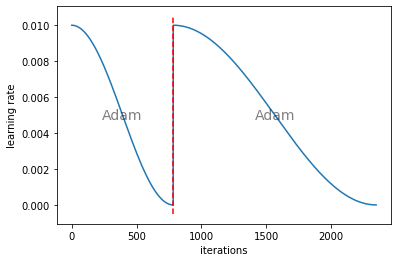

In [65]:
learn.sched.plot_lr(show_moms=False)